In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
def normalize_data(X: np.ndarray) -> np.ndarray:
    X_min = np.min(X, axis=1, keepdims=True)
    X_max = np.max(X, axis=1, keepdims=True)
    X_normalized = (X - X_min) / (X_max - X_min + 1e-8)
    return X_normalized

In [3]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [4]:
path_load = '../../source/data_source'

X_train = np.load(os.path.join(path_load, 'data_sourceY_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'data_sourceZ_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

X_test = np.load(os.path.join(path_load, 'data_sourceY_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'data_sourceZ_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

X_val = np.load(os.path.join(path_load, 'data_sourceY_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'data_sourceZ_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+


In [5]:
def plot_ecg_12_leads(data_plot, data_label=['NORM']):
    plt.figure(figsize=(24,12))
    print(f"Class {data_label}")
    ecg_leads = {
        0: "I",
        1: "II",
        2: "III",
        3: "aVR",
        4: "aVL",
        5: "aVF",
        6: "V1",
        7: "V2",
        8: "V3",
        9: "V4",
        10: "V5",
        11: "V6"
    }
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.plot(data_plot[:, i])
        plt.title(f"Lead {ecg_leads[i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

Class [1. 0. 0. 0. 0.]


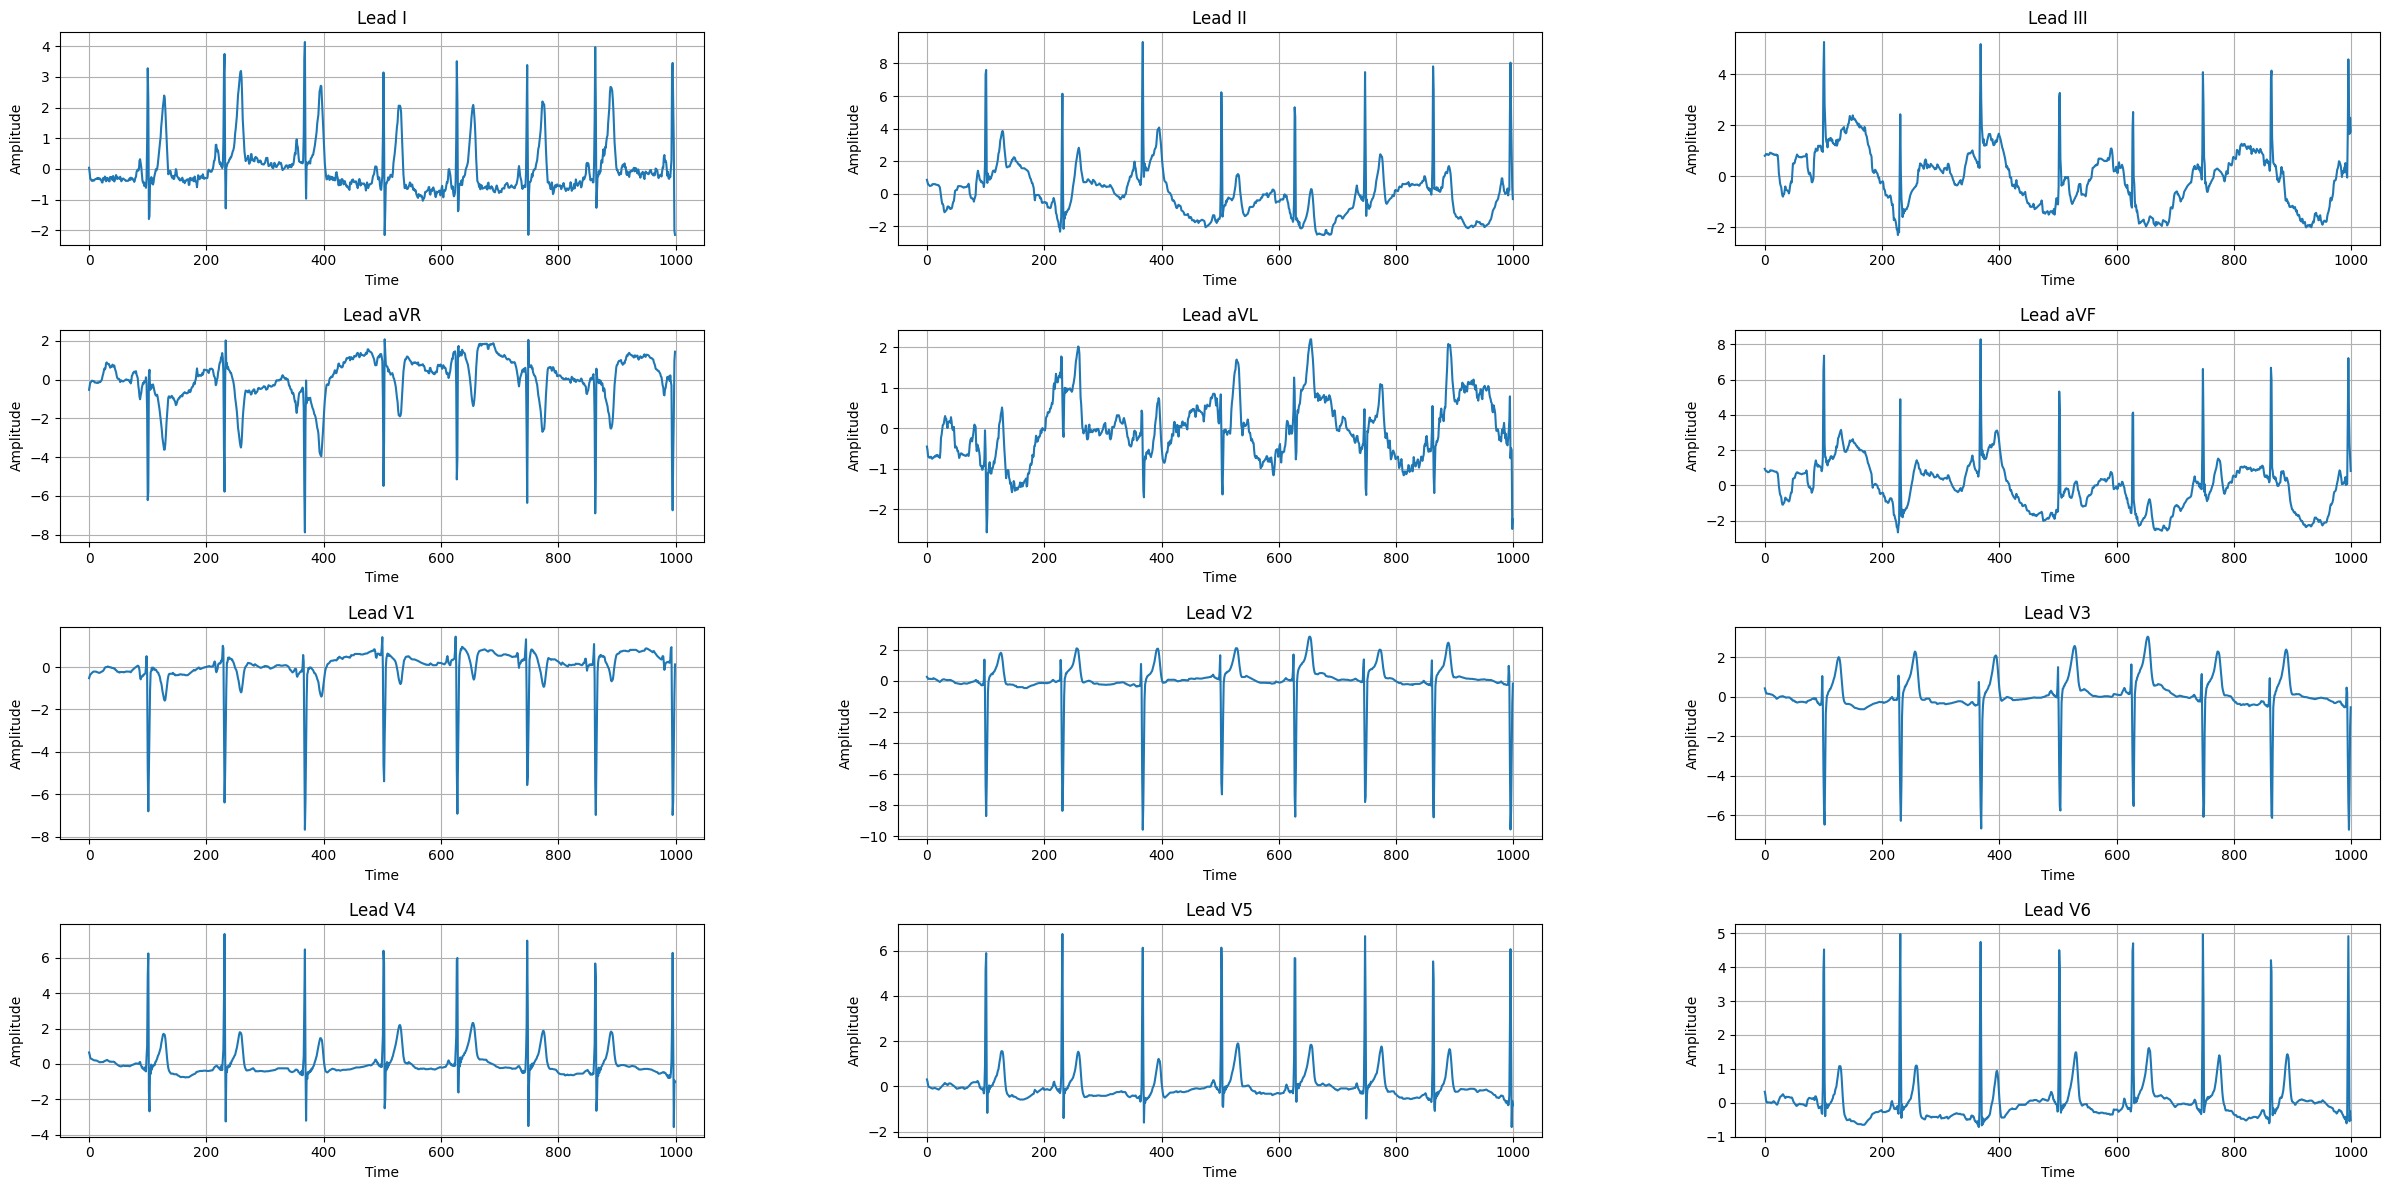

In [6]:
plot_ecg_12_leads(X_train[1, :], y_train[1])

In [7]:
x_train = torch.from_numpy(X_train).float()  # float tensor for input
labels_train = torch.from_numpy(y_train).float()  # float tensor for labels
x_val = torch.from_numpy(X_val).float()
labels_val = torch.from_numpy(y_val).float()
x_test = torch.from_numpy(X_test).float()
lables_test = torch.from_numpy(y_test).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [8]:
import torch
import torch.nn as nn
import torchaudio.transforms as T

class AttentionPool(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: [B, T, F] (sequence of features)
        scores = self.attn(x)                  # [B, T, 1]
        weights = torch.softmax(scores, dim=1) # [B, T, 1]
        out = (x * weights).sum(dim=1)         # [B, F]
        return out

class AlexNetAttentionECG(nn.Module):
    def __init__(self, input_channels = 12, n_classes=5, n_freq=129):
        super().__init__()
        self.spec_transform = nn.Sequential(
            T.Spectrogram(n_fft=256, win_length=256, hop_length=16, power=2.0),
            T.AmplitudeToDB(),
            T.FrequencyMasking(freq_mask_param=15),
            T.TimeMasking(time_mask_param=30)
        )

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=11, stride=4, padding=2),  # [B, 64, F1, T1]
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveMaxPool2d((3, 1))
        )

        self.hidden_size = 256 * 3
        self.attention = AttentionPool(hidden_size=self.hidden_size)

        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # Input: [B, T, C] → [B, C, T]

        # Spectrogram: [B, C, T] → [B, C, F, T]
        x = self.spec_transform(x)  # [B, 1, F, T]

        x = self.features(x)        # [B, C', F', T']

        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2)   # [B, T', C', F']
        x = x.reshape(B, T, -1)     # [B, T', Features]
        x = self.attention(x)       # [B, Features]
        return self.classifier(x)


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AlexNetAttentionECG().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()  

In [10]:
# 4. Training loop
num_epochs = 30
best_val_loss = float('inf')
best_model_wts = None  # To save the best model
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs.transpose(1, 2))  # CNN expects (batch, channels, seq_len)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.transpose(1, 2))
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_loader.dataset)
    
    
    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    print(f"{epoch_str} [{bar}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"Found best save with Val Loss: {val_loss:.4f}")
        best_model_wts = model.state_dict()  # Save the best model
        epochs_without_improvement = 0  # Reset the counter

model.eval()
test_loss = 0.0

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs.transpose(1, 2))
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/30 [=-----------------------------] | Train Loss: 0.4545 | Val Loss: 0.5043
Found best save with Val Loss: 0.5043
Epoch 2/30 [==----------------------------] | Train Loss: 0.4142 | Val Loss: 0.4154
Found best save with Val Loss: 0.4154
Epoch 3/30 [===---------------------------] | Train Loss: 0.3971 | Val Loss: 0.4245
Epoch 4/30 [====--------------------------] | Train Loss: 0.3885 | Val Loss: 0.4688
Epoch 5/30 [=====-------------------------] | Train Loss: 0.3826 | Val Loss: 0.3982
Found best save with Val Loss: 0.3982
Epoch 6/30 [======------------------------] | Train Loss: 0.3763 | Val Loss: 0.3871
Found best save with Val Loss: 0.3871
Epoch 7/30 [=======-----------------------] | Train Loss: 0.3736 | Val Loss: 0.3919
Epoch 8/30 [========----------------------] | Train Loss: 0.3688 | Val Loss: 0.3949
Epoch 9/30 [=========---------------------] | Train Loss: 0.3630 | Val Loss: 0.4103
Epoch 10/30 [==========--------------------] | Train Loss: 0.3593 | Val Loss: 0.3913
Epoch 1

In [11]:
def performance_evaluation(model=model, dataset = test_loader, dataset_name = "Test Set"):
    
    all_targets = []
    all_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets in dataset:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.transpose(1, 2))
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    num_classes = all_targets.shape[1]

    # Prepare table data
    table_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP"]

    for i in range(num_classes):
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            i,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            f"{f1_score:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    return all_targets, all_preds

In [12]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")


------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+-------------+--------------+--------------+
|   Class |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP          | FN           | TP           |
+=========+=============+========================+===============+============+===============+=============+==============+==============+
|       0 |      0.8695 |                 0.8149 |        0.9054 |     0.8413 | 8893 (51.1%)  | 929 (5.3%)  | 1406 (8.1%)  | 6190 (35.5%) |
+---------+-------------+------------------------+---------------+------------+---------------+-------------+--------------+--------------+
|       1 |      0.7833 |                 0.544  |        0.9495 |     0.642  | 12380 (71.1%) | 659 (3.8%)  | 1997 (11.5%) | 2382 (13.7%) |
+---------+-------------+------------------------+---------------+------------+---

In [13]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


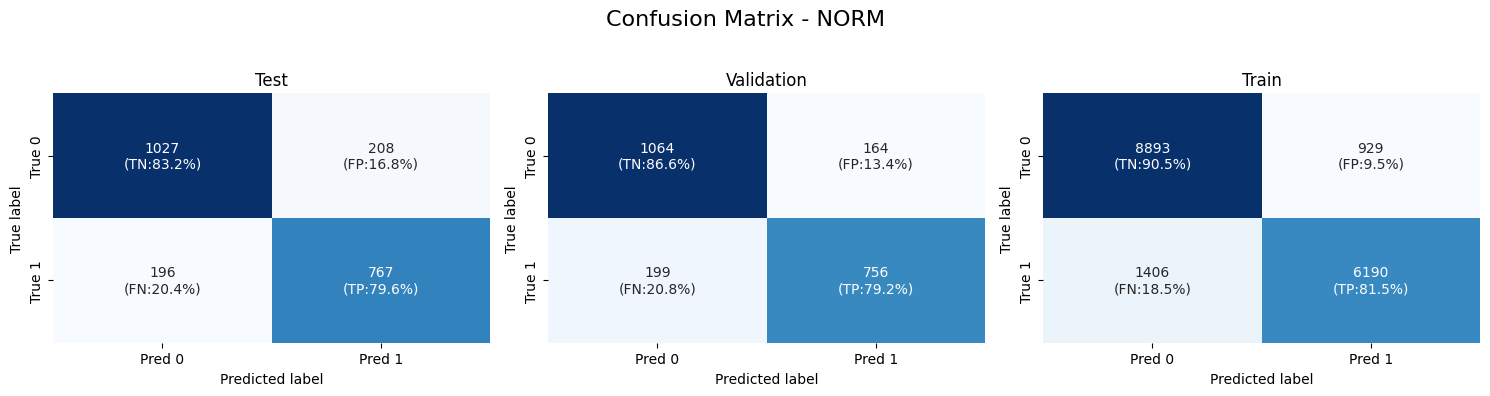

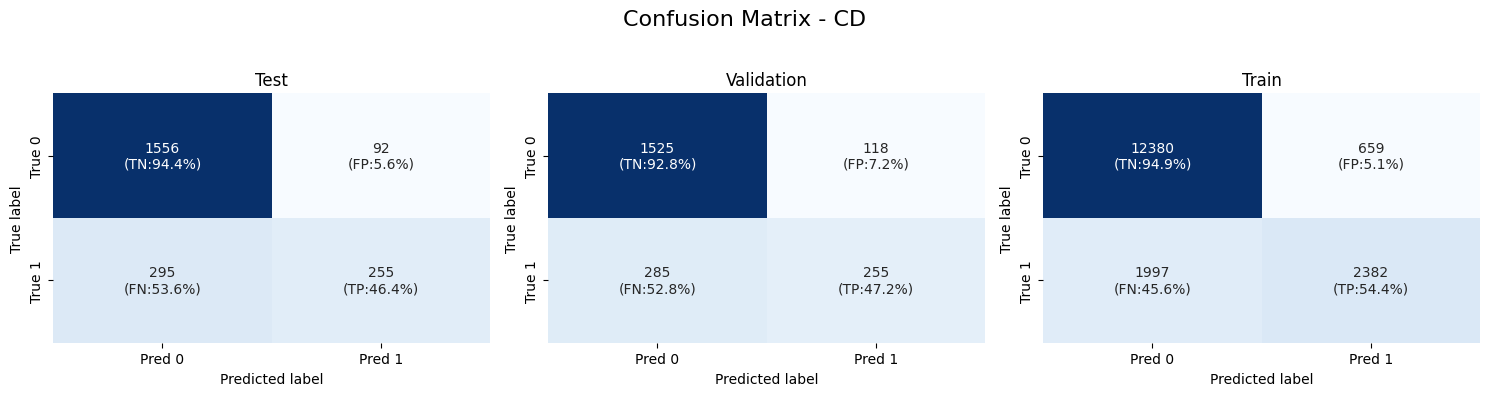

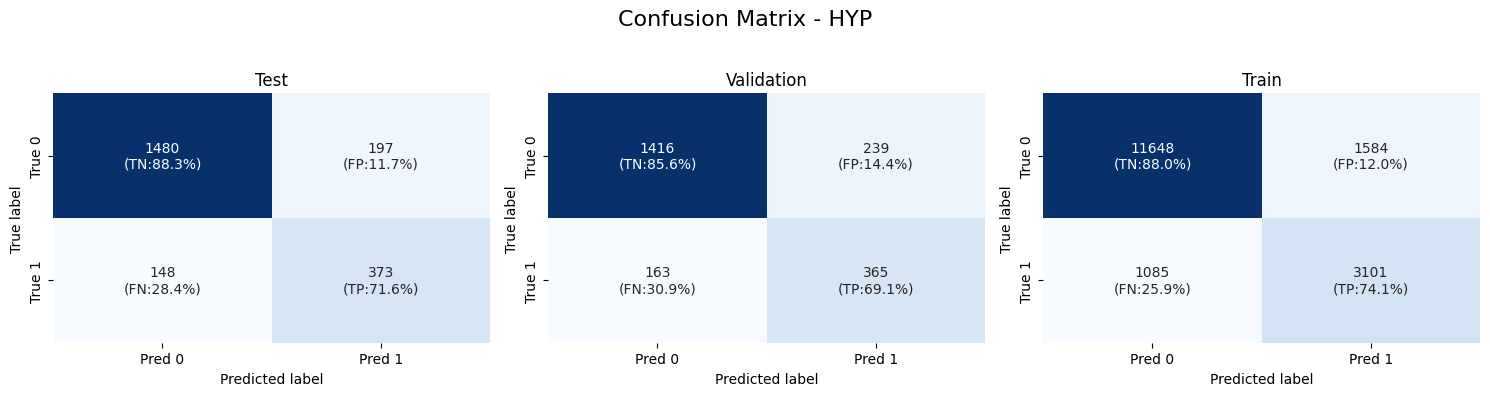

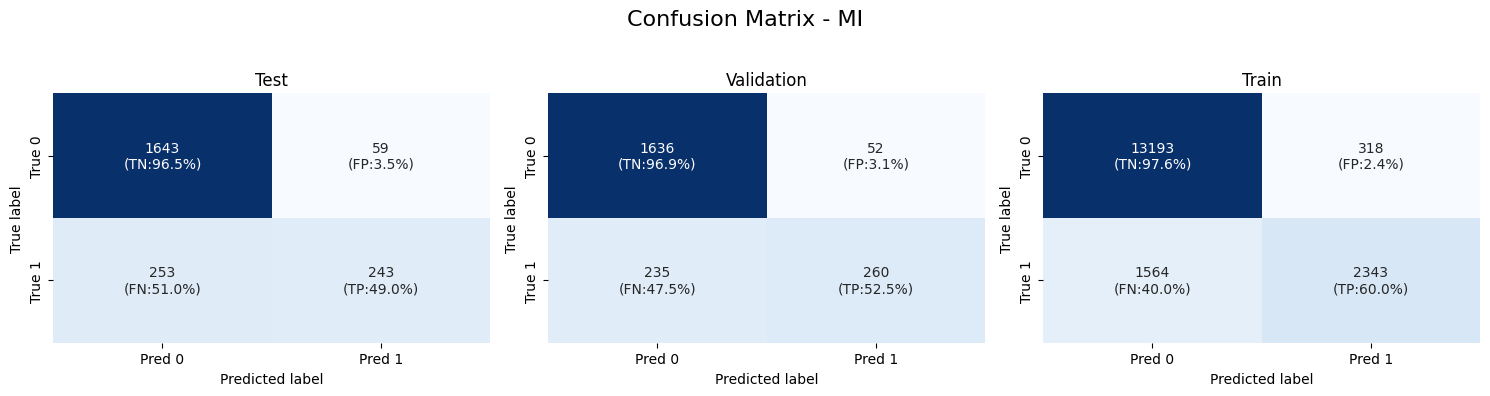

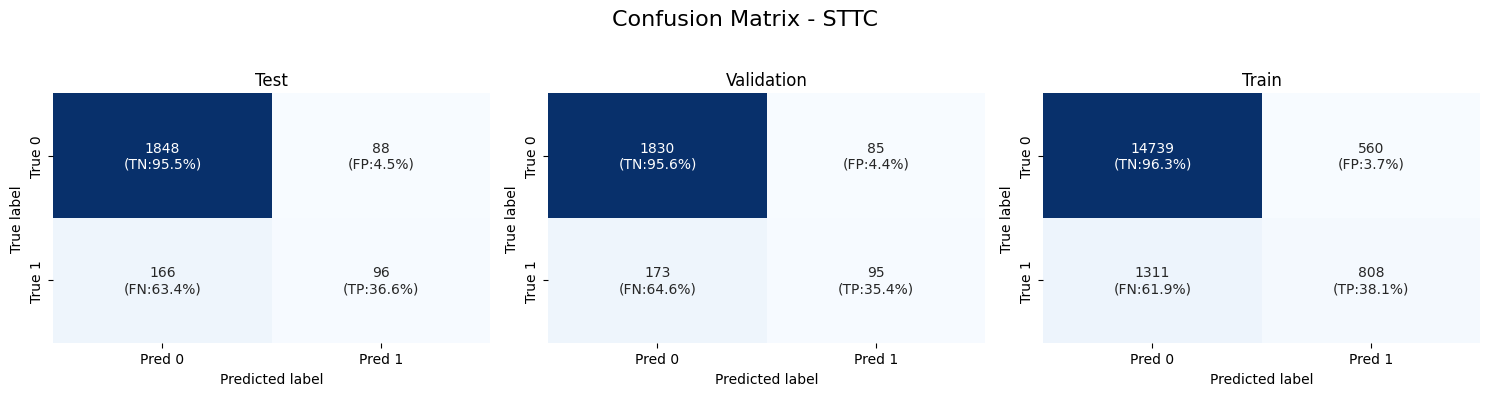

In [14]:
classes_name = {'NORM': 0, 'CD': 1, 'HYP': 2, 'MI': 3, 'STTC': 4}
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(classes_name.keys()),
    set_names=set_names
)